In [1]:
import os
import pickle
import psycopg2
import numpy as np
import pandas as pd
import FinanceDataReader as fdr

import ustreasurycurve as ustcurve

from typing import List
from collections import namedtuple
from itertools import repeat, product
from nelson_siegel_svensson.calibrate import calibrate_nss_ols

from load_portfolio import get_idiosyncratic_ids
from Library.PayoffFactory import payoff_mc_factory
from Library.Utility import year_frac, UST_TENOR_MAP, get_fixings_vec
from Library.Interpolation import pchip_interpolator2d
from Library.Parameters import ParametersConstant
from Library.Random import RandomMT19937
from Library.StatisticsMC import StatisticsMCMean
from Library.ExoticEngine import ExoticEngineBlackScholesMerton
from Library.OptionPricerBSM1973 import BlackScholesMertonCall, BlackScholesMertonPut
from Library.RiskEngineKimYi2025 import pmle_kimyirisk_systematic, pmle_kimyirisk_idiosyncratic, KimYiRiskEngine
from Library.PathDependent import PathDependentAsianDiscrete

import matplotlib
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter

az.style.use("arviz-darkgrid")

ModuleNotFoundError: No module named 'Library'

In [4]:
valuation_beg_dt = '20250331'
valuation_end_dt = '20250416'
date_format = '%Y%m%d'
valuation_window = pd.bdate_range(pd.to_datetime(arg=valuation_beg_dt, format=date_format), pd.to_datetime(arg=valuation_end_dt, format=date_format))
valuation_window_str = [dt.strftime(date_format) for dt in valuation_window]

DIVIDEND_YIELDS = {'^SPX': 1.25, 'COIN': 0.}

lookback_period = 252
base_days = 252
delta_t = np.array(1 / base_days)
seed_number = np.uint64(20240114)
n_mc_paths = int(10_000)
m_steps = int(base_days)

# rng = RandomMT19937(seed=seed_number)

systematic_id = '^SPX'
id_dict = {'systematic_id': systematic_id, 'idiosyncratic_ids': get_idiosyncratic_ids()}

systematic_price_ts = fdr.DataReader(id_dict['systematic_id'])['Adj Close']
systematic_price_ts.name = id_dict['systematic_id']
systematic_price_ts.index.name = 'sVALUATION_DATE'

price_ts = []
for symbol in id_dict['idiosyncratic_ids']:
    tmp_df = fdr.DataReader(symbol)['Adj Close']
    tmp_df.name = symbol
    tmp_df.index.name = 'sVALUATION_DATE'
    price_ts.append(tmp_df)

price_ts = pd.concat(price_ts, axis=1)
price_ts = pd.concat([systematic_price_ts, price_ts], axis=1).ffill().bfill()
price_ts.index = pd.to_datetime(price_ts.index)
return_ts = price_ts.pct_change().dropna()

# https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics?data=yield%27
rates_data_df = ustcurve.nominalRates(pd.to_datetime(valuation_window_str[0]).strftime("%Y-%m-%d"), pd.to_datetime(valuation_window_str[-1]).strftime("%Y-%m-%d")).set_index('date')
rates_data_df = pd.DataFrame(index=pd.bdate_range(rates_data_df.index.min(), rates_data_df.index.max())).join(rates_data_df).ffill(axis=1).bfill(axis=1).ffill().bfill()

HTTPError: HTTP Error 404: Not Found

In [1]:
try:
    # Open the file in binary read mode ('rb')
    file_path = os.path.join(os.path.abspath(os.path.join(os.getcwd(), os.pardir)), rf'Study/Vol Surface From Model/kimyi2025_vol_surface.pkl')
    with open(file_path, 'rb') as file:
        # Load the pickled data
        vol_surf_df = pickle.load(file)

    # Now, 'loaded_data' contains the Python object that was saved
    print("Data successfully loaded from pickle file:")
    print(file_path)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while loading the pickle file: {e}")

An error occurred while loading the pickle file: name 'os' is not defined


In [5]:
conn = None
sys_df = None
idi_df = None
set_to_valuate_final_systematic = []
set_to_valuate_final_idiosyncratic = []

try:
    conn = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password="postgres",
        host="localhost",
        port="5432"
    )
    cur = conn.cursor()
    print("Database connected successfully")

    sql_str = f"SELECT * FROM pmle_params_kim_yi WHERE sSYSTEMATIC_ID='{systematic_id}' AND sSYSTEMATIC_ID=sIDIOSYNCRATIC_ID;"

    sys_df = pd.read_sql(sql_str, conn)
    sys_df = sys_df.set_index(['svaluation_date', 'sidiosyncratic_id', 'ssystematic_id'])

    array_of_idi_ids = None

    if len(id_dict['idiosyncratic_ids']) > 1:
        array_of_idi_ids = tuple(id_dict['idiosyncratic_ids'])
        sql_str = f"SELECT * FROM pmle_params_kim_yi WHERE sIDIOSYNCRATIC_ID IN '{array_of_idi_ids}';"
    else:
        array_of_idi_ids = id_dict['idiosyncratic_ids'][0]
        sql_str = f"SELECT * FROM pmle_params_kim_yi WHERE sIDIOSYNCRATIC_ID = '{array_of_idi_ids}';"


    idi_df = pd.read_sql(sql_str, conn)
    idi_df = idi_df.set_index(['svaluation_date', 'sidiosyncratic_id', 'ssystematic_id'])

    print("Successfully fetched data")

    set_to_valuate_total_systematic = list(product(valuation_window_str, [id_dict['systematic_id']], [id_dict['systematic_id']]))
    for tuple_to_valuate in set_to_valuate_total_systematic:
        if not tuple_to_valuate in sys_df.index:
            set_to_valuate_final_systematic.append(tuple_to_valuate)

    set_to_valuate_total_idiosyncratic = list(product(valuation_window_str, id_dict['idiosyncratic_ids'], [id_dict['systematic_id']]))
    for tuple_to_valuate in set_to_valuate_total_idiosyncratic:
        if not tuple_to_valuate in idi_df.index:
            set_to_valuate_final_idiosyncratic.append(tuple_to_valuate)

except psycopg2.OperationalError as e:
    print(f"Database not connected successfully: {e}")

finally:
    conn.close()
    print("Database connection closed")

Database connected successfully
Database connection closed


NameError: name 'systematic_id' is not defined

In [6]:
def pmle_kimyirisk_systematic_helper(args) -> List[tuple]:

    valuation_dt, return_vector, delta_t, seed_number, n_mc_paths, systematic_id, idiosyncratic_id = args

    results = pmle_kimyirisk_systematic(
        sys_returns=return_vector,
        delta_t=delta_t,
        seed_number=seed_number,
        n_mc_paths=n_mc_paths
    )

    results_list = []
    for k, v in results.items():
        stats_name1, stats_name2, stats_name3 = v._asdict().keys()
        stats1, stats2, stats3 = v._asdict().values()
        results_list.append((valuation_dt, idiosyncratic_id, systematic_id, k, stats_name1, float(stats1)))
        results_list.append((valuation_dt, idiosyncratic_id, systematic_id, k, stats_name2, float(stats2)))
        results_list.append((valuation_dt, idiosyncratic_id, systematic_id, k, stats_name3, float(stats3)))

    return results_list


def pmle_kimyirisk_idiosyncratic_helper(args) -> List[tuple]:

    valuation_dt, params_sys, return_vector, delta_t, seed_number, n_mc_paths, systematic_id, idiosyncratic_id = args

    results = pmle_kimyirisk_idiosyncratic(
        params_sys=params_sys,
        idi_returns=return_vector,
        delta_t=delta_t,
        seed_number=seed_number,
        n_mc_paths=n_mc_paths
    )

    results_list = []
    for k, v in results.items():
        stats_name1, stats_name2, stats_name3 = v._asdict().keys()
        stats1, stats2, stats3 = v._asdict().values()
        results_list.append((valuation_dt, idiosyncratic_id, systematic_id, k, stats_name1, float(stats1)))
        results_list.append((valuation_dt, idiosyncratic_id, systematic_id, k, stats_name2, float(stats2)))
        results_list.append((valuation_dt, idiosyncratic_id, systematic_id, k, stats_name3, float(stats3)))

    return results_list

In [6]:
if len(set_to_valuate_final_systematic) > 0:
    systematic_arg_list = []
    for dt, idi_id, sys_id in set_to_valuate_final_systematic:
        return_vector = return_ts.loc[return_ts.index <= dt, idi_id].iloc[-lookback_period:].to_numpy()
        systematic_arg_list.append((dt, return_vector, delta_t, seed_number, n_mc_paths, sys_id, idi_id))

In [7]:
if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    if len(set_to_valuate_final_systematic) > 0:

        valuation_dates = [dt for dt, _, _ in set_to_valuate_final_systematic]
        return_vectors = [return_ts.loc[return_ts.index <= dt, systematic_id].iloc[-lookback_period:].to_numpy() for dt, _, _ in set_to_valuate_final_systematic]
        delta_t_list = repeat(delta_t, len(set_to_valuate_final_systematic))
        seed_number_list = repeat(seed_number, len(set_to_valuate_final_systematic))
        n_mc_paths_list = repeat(n_mc_paths, len(set_to_valuate_final_systematic))
        systematic_id_list = repeat(systematic_id, len(set_to_valuate_final_systematic))
        idiosyncratic_id_list = repeat(systematic_id, len(set_to_valuate_final_systematic))

        insert_query = ("INSERT INTO pmle_params_kim_yi ("
                        "sVALUATION_DATE, sIDIOSYNCRATIC_ID, sSYSTEMATIC_ID, sPARAMETER, sVALUE_STATISTICS_DESC, sVALUE_STATISTICS"
                        ") VALUES (%s, %s, %s, %s, %s, %s)")

        with ProcessPoolExecutor() as executor:

            results = executor.map(pmle_kimyirisk_systematic_helper, valuation_dates, return_vectors, delta_t_list, seed_number_list, n_mc_paths_list, systematic_id_list, idiosyncratic_id_list)

            try:
                conn = psycopg2.connect(
                    dbname="postgres",
                    user="postgres",
                    password="postgres",
                    host="localhost",
                    port="5432"
                )
                cur = conn.cursor()
                print("Database connected successfully")

                for result in results:
                    cur.executemany(insert_query, result)
                    num_ser_committed = cur.rowcount
                    print(f"Number of ser affected by the operation: {num_ser_committed}")
                    conn.commit()
                    print("Transaction committed successfully.")

            except psycopg2.OperationalError as e:
                print(f"Database not connected successfully: {e}")

            finally:
                conn.close()
                print("Database connection closed")

In [8]:
try:
    conn = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password="postgres",
        host="localhost",
        port="5432"
    )
    cur = conn.cursor()
    print("Database connected successfully")

    sql_str = f"SELECT * FROM pmle_params_kim_yi WHERE sSYSTEMATIC_ID='{systematic_id}' AND sSYSTEMATIC_ID=sIDIOSYNCRATIC_ID;"

    sys_df = pd.read_sql(sql_str, conn)
    sys_df = sys_df.set_index(['svaluation_date', 'sidiosyncratic_id', 'ssystematic_id'])

    print("Successfully fetched data")

except psycopg2.OperationalError as e:
    print(f"Database not connected successfully: {e}")

finally:
    conn.close()
    print("Database connection closed")

Database connected successfully
Successfully fetched data
Database connection closed


/tmp/ipykernel_1384808/3085704644.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sys_df = pd.read_sql(sql_str, conn)


In [9]:
if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    idiosyncratic_arg_list = []
    for dt, idi_id, sys_id in set_to_valuate_final_idiosyncratic:
        mask  = (sys_df.index.get_level_values('svaluation_date')==dt)
        mask &= (sys_df.index.get_level_values('ssystematic_id')==sys_id)
        mask &= (sys_df.svalue_statistics_desc=='dMEAN')
        sparameter, svalue = sys_df.loc[mask, ['sparameter', 'svalue_statistics']].to_numpy().T
        params_sys = {k: v for k, v in zip(sparameter, svalue)}
        return_vector = return_ts.loc[return_ts.index <= dt, idi_id].iloc[-lookback_period:].to_numpy()
        idiosyncratic_arg_list.append((dt, params_sys, return_vector, delta_t, seed_number, n_mc_paths, sys_id, idi_id))

    insert_query = ("INSERT INTO pmle_params_kim_yi ("
                    "sVALUATION_DATE, sIDIOSYNCRATIC_ID, sSYSTEMATIC_ID, sPARAMETER, sVALUE_STATISTICS_DESC, sVALUE_STATISTICS"
                    ") VALUES (%s, %s, %s, %s, %s, %s)")

    with ProcessPoolExecutor() as executor:

        results = executor.map(pmle_kimyirisk_idiosyncratic_helper, idiosyncratic_arg_list)

        try:
            conn = psycopg2.connect(
                dbname="postgres",
                user="postgres",
                password="postgres",
                host="localhost",
                port="5432"
            )
            cur = conn.cursor()
            print("Database connected successfully")

            for result in results:
                cur.executemany(insert_query, result)
                num_ser_committed = cur.rowcount
                conn.commit()
                print("Transaction committed successfully.")

        except psycopg2.OperationalError as e:
            print(f"Database not connected successfully: {e}")

        finally:
            conn.close()
            print("Database connection closed")

Database connected successfully
Database connection closed


In [10]:
try:
    conn = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password="postgres",
        host="localhost",
        port="5432"
    )
    print("Database connected successfully")

    select_query = f"SELECT * FROM pmle_params_kim_yi;"

    params_df = pd.read_sql(select_query, con=conn)

except psycopg2.OperationalError as e:
    print(f"Database not connected successfully: {e}")

finally:
    conn.close()
    print("Database connection closed")

Database connected successfully
Database connection closed


/tmp/ipykernel_1384808/1671321291.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  params_df = pd.read_sql(select_query, con=conn)


In [308]:
def simulate_shock_returns_systematic_helper(inputs: dict) -> dict:
    id = inputs["sID"]
    valuation_date = inputs["sVALUATION_DATE"]
    scenario_number = inputs["sSCENARIO"]
    params = inputs["oPARAMS"]
    rng = inputs["oRNG"]
    delta_time = inputs["dDELTA_TIME"]
    size = inputs["oSIZE"]

    ret, _, _ = KimYiRiskEngine(
        mui=[ParametersConstant(np.array(0.))],
        kappai=[ParametersConstant(np.array(0.))],
        gammai=[ParametersConstant(np.array(1.))],
        betai=[ParametersConstant(np.array(1.))],
        rhoix=[ParametersConstant(np.array(0.))],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=delta_time
    ).random(rng=rng, size=size)
    return {f"{valuation_date}-{id}-{scenario_number}": ret[0]}


def simulate_shock_returns_idiosyncratic_helper(inputs: dict) -> dict:
    id = inputs["sID"]
    valuation_date = inputs["sVALUATION_DATE"]
    scenario_number = inputs["sSCENARIO"]
    params = inputs["oPARAMS"]
    rng = inputs["oRNG"]
    delta_time = inputs["dDELTA_TIME"]
    size = inputs["oSIZE"]

    ret, _, _ = KimYiRiskEngine(
        mui=[ParametersConstant(params.dMUI)],
        kappai=[ParametersConstant(params.dKAPPAI)],
        gammai=[ParametersConstant(params.dGAMMAI)],
        betai=[ParametersConstant(params.dBETAI)],
        rhoix=[ParametersConstant(params.dRHOIX)],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=delta_time
    ).random(rng=rng, size=size)
    return {f"{id}-{valuation_date}-{scenario_number}": ret[0]}


def simulate_shock_returns_idiosyncratic_base_helper(inputs: dict) -> dict:
    id = inputs["sID"]
    valuation_date = inputs["sVALUATION_DATE"]
    scenario_number = inputs["sSCENARIO"]
    params = inputs["oPARAMS"]
    rng = inputs["oRNG"]
    delta_time = inputs["dDELTA_TIME"]
    size = inputs["oSIZE"]

    ret, _, _ = KimYiRiskEngine(
        mui=[ParametersConstant(params.dMUI)],
        kappai=[ParametersConstant(params.dKAPPAI)],
        gammai=[ParametersConstant(np.array(0.))],
        betai=[ParametersConstant(np.array(0.))],
        rhoix=[ParametersConstant(np.array(0.))],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=delta_time
    ).random(rng=rng, size=size)
    return {f"{id}-{valuation_date}-{scenario_number}": ret[0]}


def est_liquidity_process_sys_helper(inputs: dict) -> dict:
    id = inputs["sID"]
    valuation_date = inputs["sVALUATION_DATE"]
    scenario_number = inputs["sSCENARIO"]
    params = inputs["oPARAMS"]
    delta_time = inputs["dDELTA_TIME"]

    ret = KimYiRiskEngine(
        mui=[ParametersConstant(np.array(0.))],
        kappai=[ParametersConstant(np.array(0.))],
        gammai=[ParametersConstant(np.array(1.))],
        betai=[ParametersConstant(np.array(1.))],
        rhoix=[ParametersConstant(np.array(0.))],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=delta_time
    ).est_liquidity_process(return_ts.loc[return_ts.index <= valuation_date, id].iloc[-lookback_period:].to_numpy().reshape((-1, 1)))

    return {f"{id}-{valuation_date}-{scenario_number}": ret}


def est_liquidity_process_idi_helper(inputs: dict) -> dict:
    id = inputs["sID"]
    valuation_date = inputs["sVALUATION_DATE"]
    scenario_number = inputs["sSCENARIO"]
    params = inputs["oPARAMS"]
    delta_time = inputs["dDELTA_TIME"]

    ret = KimYiRiskEngine(
        mui=[ParametersConstant(params.dMUI)],
        kappai=[ParametersConstant(params.dKAPPAI)],
        gammai=[ParametersConstant(params.dGAMMAI)],
        betai=[ParametersConstant(params.dBETAI)],
        rhoix=[ParametersConstant(params.dRHOIX)],
        alpha=ParametersConstant(params.dALPHA),
        sigma=ParametersConstant(params.dSIGMA),
        pprob=ParametersConstant(params.dPPROB),
        lamb=ParametersConstant(params.dLAMB),
        eta1=ParametersConstant(params.dETA1),
        eta2=ParametersConstant(params.dETA2),
        end_dt=delta_time
    ).est_liquidity_process(return_ts.loc[return_ts.index <= valuation_date, id].iloc[-lookback_period:].to_numpy().reshape((-1, 1)))

    return {f"{id}-{valuation_date}-{scenario_number}": ret}

In [373]:
point_in_time_dt = '20250403'

inputs_sys = []
inputs_idi = []
inputs_idi_base = []

# mask = (params_df.svaluation_date==point_in_time_dt) & (params_df.sidiosyncratic_id=='COIN') & (params_df.svalue_statistics_desc=='dMEAN')
# series1 = params_df.loc[mask, ['sparameter', 'svalue_statistics']].set_index('sparameter').svalue_statistics
#
# range_gammai = np.sort(np.concat((np.linspace(0., 3., 7), np.array([series1.dGAMMAI]))))
# range_betai = np.sort(np.concat((np.linspace(0., 3., 7), np.array([series1.dBETAI]))))
# range_rhoix = np.sort(np.concat((np.linspace(-1., 1., 5), np.array([series1.dRHOIX]))))
# what_if_scenarios_dict = {f"SCEN_{k+1}": v for k, v in enumerate(product(range_gammai, range_betai, range_rhoix))}

range_gammai = np.linspace(0., 3., 7)
range_betai = np.linspace(0., 3., 7)
range_rhoix = np.linspace(-1., 1., 5)
what_if_scenarios_dict = {f"SCEN_{k+1}": v for k, v in enumerate(product(range_gammai, range_betai, range_rhoix))}

what_if_scenario_df = pd.DataFrame(what_if_scenarios_dict).T
what_if_scenario_df.columns = ['dGAMMAI', 'dBETAI', 'dRHOIX']
what_if_scenario_df.index.name = 'sSCENARIO'
what_if_scenario_df.to_csv(os.path.join(os.getcwd(), r'Scenarios/what_if_scenarios.csv'))

do_what_if_scenario = True

for dt, idi_id in product([pd.to_datetime(point_in_time_dt)], get_idiosyncratic_ids()):
    dt = dt.strftime(date_format)

    rng.reset()

    mask = (params_df.svaluation_date==dt) & (params_df.sidiosyncratic_id==systematic_id) & (params_df.svalue_statistics_desc=='dMEAN')
    series1 = params_df.loc[mask, ['sparameter', 'svalue_statistics']].set_index('sparameter').svalue_statistics
    inputs_sys.append(
        {"sID": systematic_id, "sVALUATION_DATE": dt, "sSCENARIO": "SCEN_0", "oPARAMS": series1, "oRNG": rng, "dDELTA_TIME": delta_t, "oSIZE": (1, n_mc_paths, m_steps)}
    )

    rng.reset()

    mask = (params_df.svaluation_date==dt) & (params_df.sidiosyncratic_id==idi_id) & (params_df.svalue_statistics_desc=='dMEAN')
    series2 = params_df.loc[mask, ['sparameter', 'svalue_statistics']].set_index('sparameter').svalue_statistics
    series0 = pd.concat([series2, series1])
    inputs = {"sID": idi_id, "sVALUATION_DATE": dt, "sSCENARIO": "SCEN_0", "oPARAMS": series0, "oRNG": rng, "dDELTA_TIME": delta_t, "oSIZE": (1, n_mc_paths, m_steps)}
    inputs_idi.append(inputs)
    inputs_idi_base.append(inputs)

    # what-if scenarios
    if do_what_if_scenario:
        what_if_scenarios_dict["SCEN_0"] = (series2.dGAMMAI, series2.dBETAI, series2.dRHOIX)

        for scen_no, v in what_if_scenarios_dict.items():
            rng.reset()

            gammai, betai, rhoix = v

            series2.dGAMMAI = gammai
            series2.dBETAI = betai
            series2.dRHOIX = rhoix

            series0 = pd.concat([series2, series1])
            inputs_idi.append(
                {"sID": idi_id, "sVALUATION_DATE": dt, "sSCENARIO": scen_no, "oPARAMS": series0, "oRNG": rng, "dDELTA_TIME": delta_t, "oSIZE": (1, n_mc_paths, m_steps)}
            )

In [374]:
if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    with ProcessPoolExecutor() as executor:

        results1 = executor.map(simulate_shock_returns_systematic_helper, inputs_sys)
        results2 = executor.map(simulate_shock_returns_idiosyncratic_helper, inputs_idi)
        results3 = executor.map(simulate_shock_returns_idiosyncratic_base_helper, inputs_idi_base)
        results4 = executor.map(est_liquidity_process_sys_helper, inputs_sys)
        results5 = executor.map(est_liquidity_process_idi_helper, inputs_idi)

        shock_returns_sys_dict = {}
        shock_returns_idi_dict = {}
        shock_returns_idi_base_dict = {}
        liquidity_process_sys_dict = {}
        liquidity_process_idi_dict = {}

        for result1 in results1:
            for date_key, inner_dict in result1.items():
                shock_returns_sys_dict[date_key] = inner_dict

        for result2 in results2:
            for date_key, inner_dict in result2.items():
                shock_returns_idi_dict[date_key] = inner_dict

        for result3 in results3:
            for date_key, inner_dict in result3.items():
                shock_returns_idi_base_dict[date_key] = inner_dict

        for result4 in results4:
            for date_key, inner_dict in result4.items():
                liquidity_process_sys_dict[date_key] = inner_dict

        for result5 in results5:
            for date_key, inner_dict in result5.items():
                liquidity_process_idi_dict[date_key] = inner_dict

In [375]:
cmp_ret = (1 + shock_returns_idi_dict[f"COIN-{point_in_time_dt}-SCEN_0"])
cmp_ret_base = (1 + shock_returns_idi_base_dict[f"COIN-{point_in_time_dt}-SCEN_0"])

for i in range(1, cmp_ret.shape[1] - 1):
    cmp_ret[:, i] *= cmp_ret[:, i-1]
    cmp_ret_base[:, i] *= cmp_ret_base[:, i-1]

cmp_ret = cmp_ret - 1.
cmp_ret_base = cmp_ret_base - 1.

In [376]:
df1 = pd.DataFrame(data=cmp_ret)
df2 = pd.DataFrame(data=cmp_ret_base)
df1['Return Assumption'] = 'LA'
df2['Return Assumption'] = 'BS'
simulated_returns_df = pd.concat([df1, df2])
simulated_returns_df = simulated_returns_df.set_index('Return Assumption')

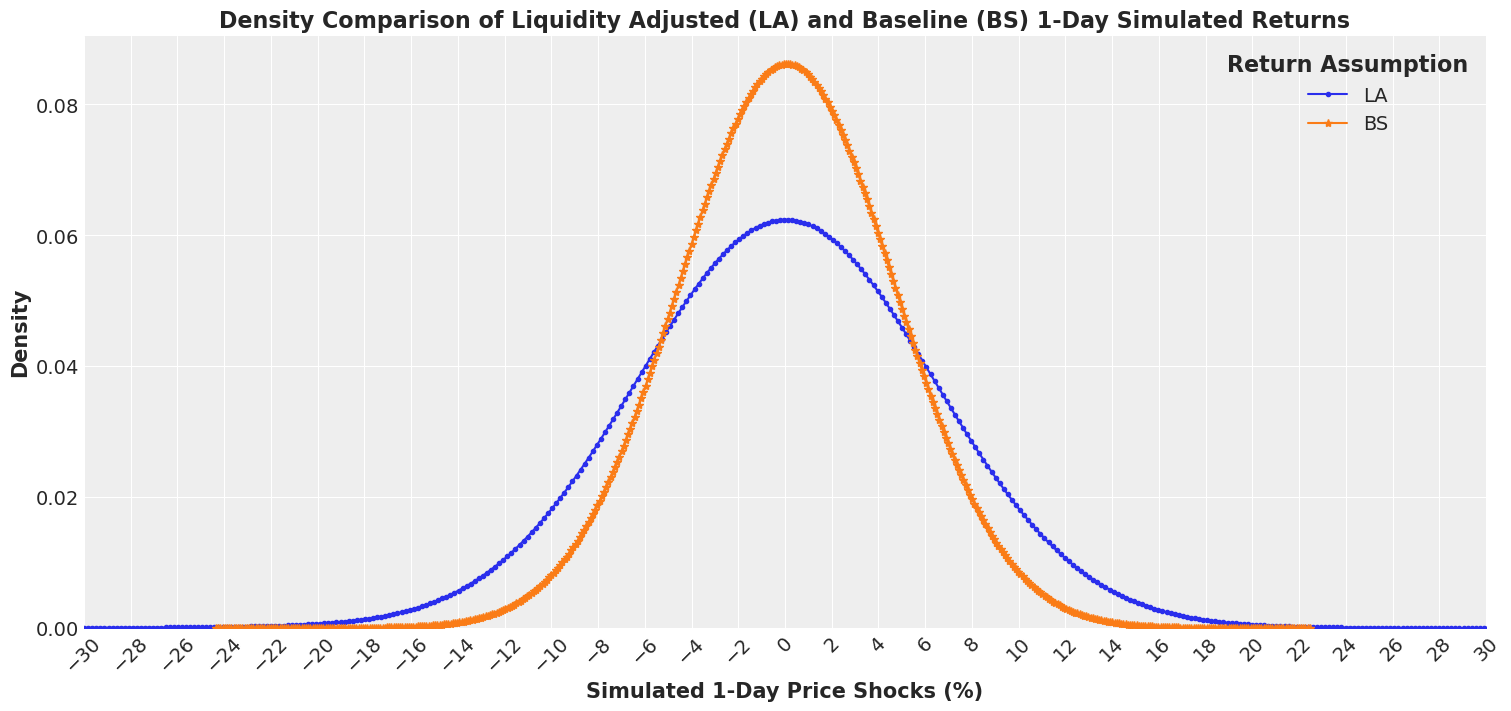

In [377]:
h = 1

az.style.use("arviz-darkgrid")
fig, ax = plt.subplots(figsize=(15, 7))

sns.kdeplot(data=simulated_returns_df.xs('LA') * 100., x=h, fill=False, gridsize=500, bw_adjust=5., marker='.', label='LA', ax=ax)
sns.kdeplot(data=simulated_returns_df.xs('BS') * 100., x=h, fill=False, gridsize=500, bw_adjust=5., marker='*', label='BS', ax=ax)

# ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(2))
ax.tick_params(axis='x', which='both', labelrotation=45)

ax.set_title(f'Density Comparison of Liquidity Adjusted (LA) and Baseline (BS) {h}-Day Simulated Returns', fontweight='bold')
ax.set_xlabel(f"Simulated {h}-Day Price Shocks (%)", fontweight='bold')
ax.set_ylabel("Density", fontweight='bold')
ax.legend(title='Return Assumption')

plt.setp(ax.get_legend().get_title(), fontsize='16', fontweight='bold')
plt.xlim(-30, 30)
plt.savefig("density_simulated_returns.pdf", dpi=300)
plt.show()

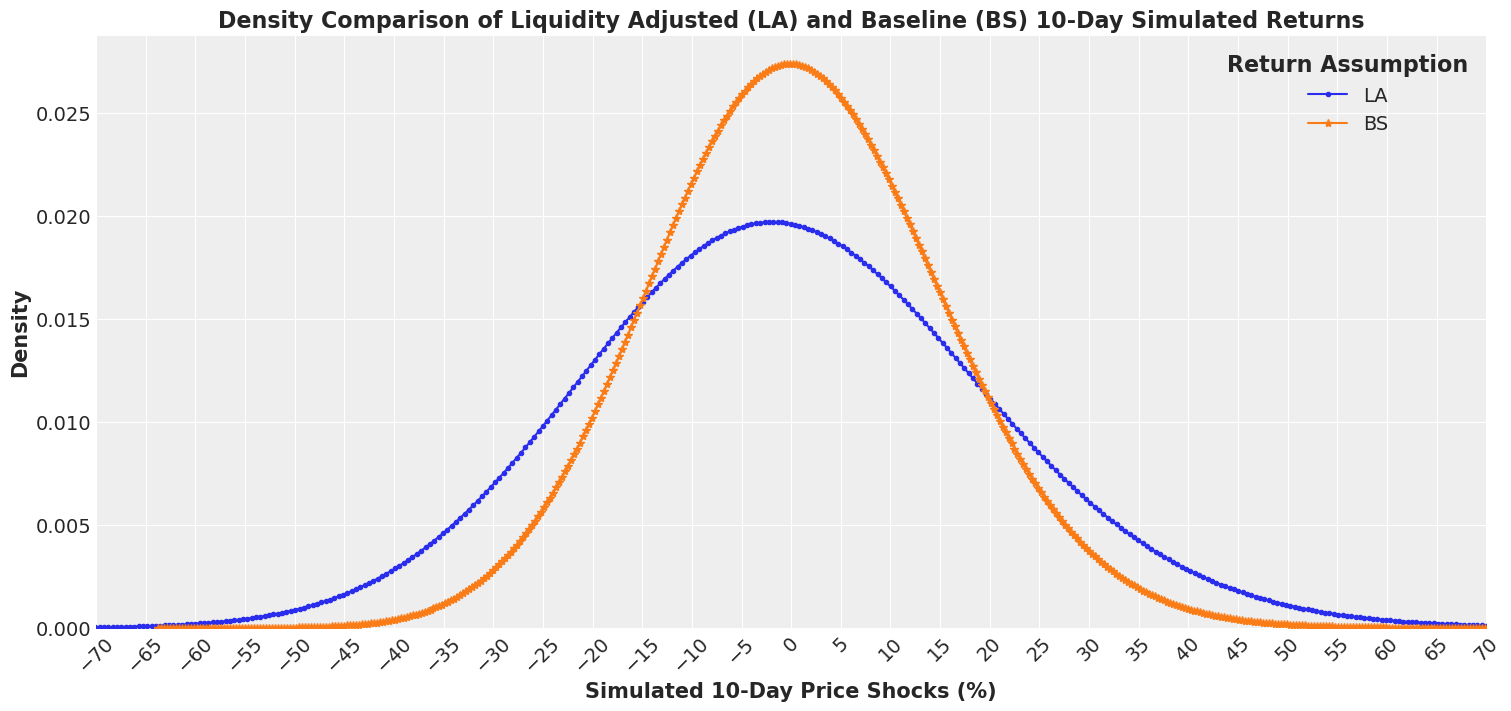

In [378]:
h = 10

az.style.use("arviz-darkgrid")
fig, ax = plt.subplots(figsize=(15, 7))

sns.kdeplot(data=simulated_returns_df.xs('LA') * 100., x=h, fill=False, gridsize=500, bw_adjust=5., marker='.', label='LA', ax=ax)
sns.kdeplot(data=simulated_returns_df.xs('BS') * 100., x=h, fill=False, gridsize=500, bw_adjust=5., marker='*', label='BS', ax=ax)

# ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.tick_params(axis='x', which='both', labelrotation=45)

ax.set_title(f'Density Comparison of Liquidity Adjusted (LA) and Baseline (BS) {h}-Day Simulated Returns', fontweight='bold')
ax.set_xlabel(f"Simulated {h}-Day Price Shocks (%)", fontweight='bold')
ax.set_ylabel("Density", fontweight='bold')
ax.legend(title='Return Assumption')

plt.setp(ax.get_legend().get_title(), fontsize='16', fontweight='bold')
plt.xlim(-70, 70)
plt.savefig("density_simulated_returns_10d.pdf", dpi=300)
plt.show()

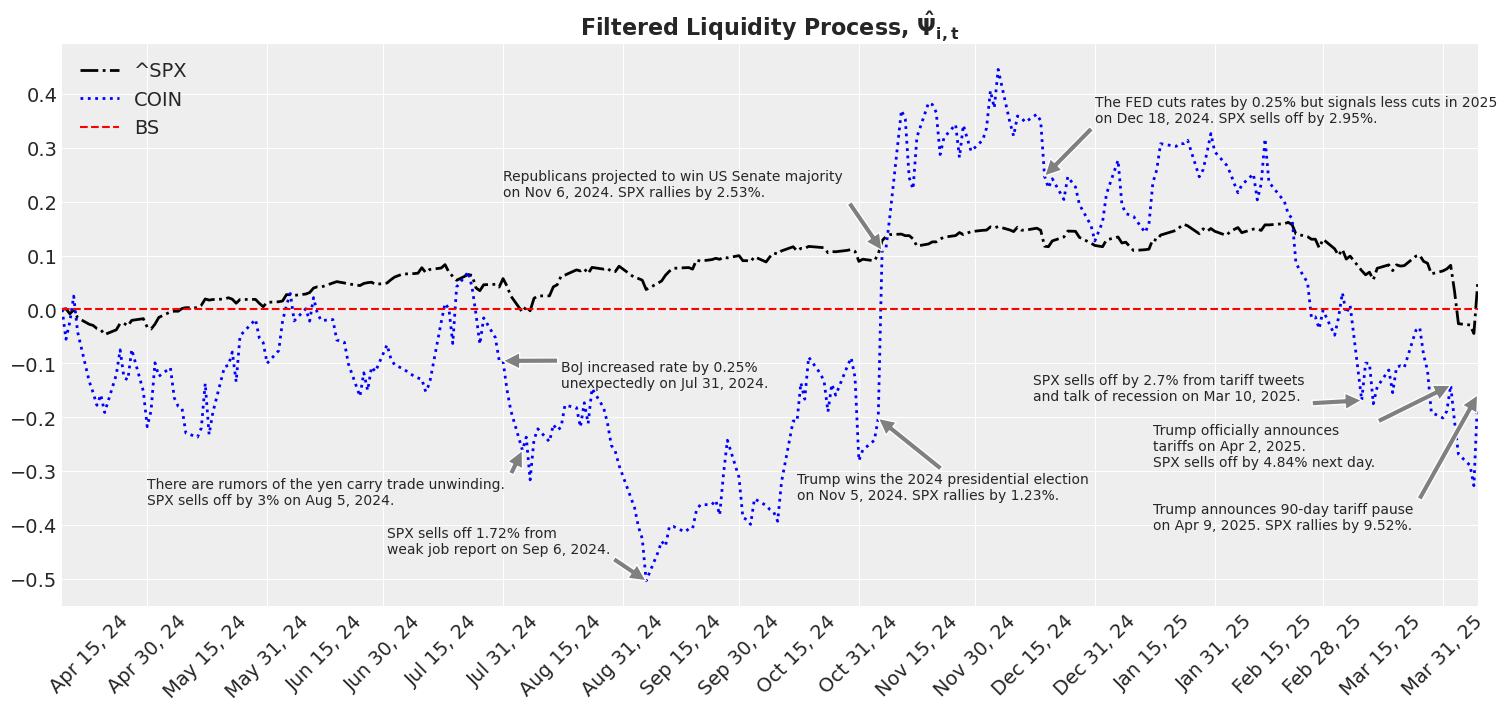

In [362]:
# liquidity process for last date
index = return_ts.loc[return_ts.index <= pd.to_datetime(point_in_time_dt)].iloc[-lookback_period - 1:].index

liquidity_process_df = pd.concat(
    [pd.Series(liquidity_process_sys_dict[f'{id_dict['systematic_id']}-{point_in_time_dt}-SCEN_0'].squeeze(), index=index, name=id_dict['systematic_id'])] +
    [pd.Series(liquidity_process_idi_dict[f'{id}-{point_in_time_dt}-SCEN_0'].squeeze(), index=index, name=id) for id in id_dict['idiosyncratic_ids']],
    axis=1
)

sys_idi = id_dict['systematic_id']
idi_idi = 'COIN'

fig, ax = plt.subplots(figsize=(15, 7))

sns.lineplot(x=liquidity_process_df.index, y=liquidity_process_df[sys_idi].squeeze(), ax=ax, label=rf'{sys_idi}', color='black', linestyle='-.', linewidth=2)
sns.lineplot(x=liquidity_process_df.index, y=liquidity_process_df[idi_idi].squeeze(), ax=ax, label=rf'{idi_idi}', color='blue', linestyle=':', linewidth=2)
sns.lineplot(x=liquidity_process_df.index, y=0, ax=ax, color='red', linestyle='--', linewidth=1.5, label='BS')

ax.set_xlabel(None)
ax.set_ylabel(None)
# ax.legend(title='Underlying Tickers', title_fontproperties={'weight': 'bold', 'size': 'large'})
ax.set_title(r'Filtered Liquidity Process, $\mathbf{{\hat{\Psi}_{{i, t}}}}$', fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=-1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %y'))
ax.xaxis.set_minor_locator(mdates.DayLocator(bymonthday=15))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b %d, %y'))
ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(.1))

ax.tick_params(axis='x', which='both', labelrotation=45)

ax.annotate(
    text="BoJ increased rate by 0.25% \nunexpectedly on Jul 31, 2024.",
    xy=(pd.to_datetime('20240731'), liquidity_process_df.xs('20240731')[idi_idi]),
    xytext=(pd.to_datetime('20240815'), liquidity_process_df.xs('20240731')[idi_idi] - .05),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="There are rumors of the yen carry trade unwinding. \nSPX sells off by 3% on Aug 5, 2024.",
    xy=(pd.to_datetime('20240805'), liquidity_process_df.xs('20240805')[idi_idi]),
    xytext=(pd.to_datetime('20240430'), liquidity_process_df.xs('20240805')[idi_idi] - .1),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="SPX sells off 1.72% from \nweak job report on Sep 6, 2024.",
    xy=(pd.to_datetime('20240906'), liquidity_process_df.xs('20240906')[idi_idi]),
    xytext=(pd.to_datetime('20240701'), liquidity_process_df.xs('20240906')[idi_idi] + .05),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Trump wins the 2024 presidential election \non Nov 5, 2024. SPX rallies by 1.23%.",
    xy=(pd.to_datetime('20241105'), liquidity_process_df.xs('20241105')[idi_idi]),
    xytext=(pd.to_datetime('20241015'), liquidity_process_df.xs('20241105')[idi_idi] - .15),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Republicans projected to win US Senate majority \non Nov 6, 2024. SPX rallies by 2.53%.",
    xy=(pd.to_datetime('20241106'), liquidity_process_df.xs('20241106')[idi_idi]),
    xytext=(pd.to_datetime('20240731'), liquidity_process_df.xs('20241106')[idi_idi] + .1),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="The FED cuts rates by 0.25% but signals less cuts in 2025 \non Dec 18, 2024. SPX sells off by 2.95%.",
    xy=(pd.to_datetime('20241218'), liquidity_process_df.xs('20241218')[idi_idi]),
    xytext=(pd.to_datetime('20241231'), liquidity_process_df.xs('20241218')[idi_idi] + .1),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="SPX sells off by 2.7% from tariff tweets \nand talk of recession on Mar 10, 2025.",
    xy=(pd.to_datetime('20250310'), liquidity_process_df.xs('20250310')[idi_idi]),
    xytext=(pd.to_datetime('20241215'), liquidity_process_df.xs('20250310')[idi_idi]),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Trump officially announces \ntariffs on Apr 2, 2025. \nSPX sells off by 4.84% next day.",
    xy=(pd.to_datetime('20250402'), liquidity_process_df.xs('20250402')[idi_idi]),
    xytext=(pd.to_datetime('20250115'), liquidity_process_df.xs('20250402')[idi_idi] - .15),
    arrowprops=dict(facecolor='grey')
)

ax.annotate(
    text="Trump announces 90-day tariff pause \non Apr 9, 2025. SPX rallies by 9.52%.",
    xy=(pd.to_datetime('20250409'), liquidity_process_df.xs('20250409')[idi_idi]),
    xytext=(pd.to_datetime('20250115'), liquidity_process_df.xs('20250409')[idi_idi] - .25),
    arrowprops=dict(facecolor='grey')
)

# plt.tight_layout()
plt.xlim(index[0], index[-1])
plt.savefig("filtered_liquidity_process.pdf", dpi=300)
plt.show();

In [379]:
try:
    conn = psycopg2.connect(
        dbname="postgres",
        user="postgres",
        password="postgres",
        host="localhost",
        port="5432"
    )
    print("Database connected successfully")

    select_query = f"SELECT * FROM portfolio;"

    pos_df = pd.read_sql(select_query, con=conn)

except psycopg2.OperationalError as e:
    print(f"Database not connected successfully: {e}")

finally:
    conn.close()
    print("Database connection closed")

Database connected successfully
Database connection closed


/tmp/ipykernel_1384808/1406466721.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pos_df = pd.read_sql(select_query, con=conn)


In [380]:
def get_pv(args_dict: dict) -> dict:

    sTYPOLOGY = args_dict["sTYPOLOGY"]

    if sTYPOLOGY.lower() == 'vanilla':

        return _get_pv_vanilla(args_dict)

    else:

        return _get_pv_exotic(args_dict)


def _get_pv_vanilla(args: dict) -> dict:

    dSPOT_PRICE = args["dSPOT_PRICE"]
    dSTRIKE_PRICE = args["dSTRIKE_PRICE"]
    dRISK_FREE_RATE = args["dRISK_FREE_RATE"]
    dDIVIDEND_YIELD = args["dDIVIDEND_YIELD"]
    dIMP_VOLATILITY = args["dIMP_VOLATILITY"]
    iQUANTITY = args["iQUANTITY"]
    dEXPIRY = args['dEXPIRY']

    sPAYOFF = args["sPAYOFF"]

    if sPAYOFF.lower() == "put":

        pricer_obj = BlackScholesMertonPut(
            und_price=dSPOT_PRICE,
            und_strike=dSTRIKE_PRICE,
            risk_free_rate=dRISK_FREE_RATE,
            dividend_yield=dDIVIDEND_YIELD,
            time_to_expiry=dEXPIRY
        )

    elif sPAYOFF.lower() == "call":

        pricer_obj = BlackScholesMertonCall(
            und_price=dSPOT_PRICE,
            und_strike=dSTRIKE_PRICE,
            risk_free_rate=dRISK_FREE_RATE,
            dividend_yield=dDIVIDEND_YIELD,
            time_to_expiry=dEXPIRY
        )

    else:
        raise()

    pv = pricer_obj.price(dIMP_VOLATILITY) * iQUANTITY

    output = {
        'sVALUATION_DATE': args["sVALUATION_DATE"],
        'sID': args["sID"],
        'sTYPOLOGY': args["sTYPOLOGY"],
        'sSTRATEGY': args["sSTRATEGY"],
        'sPAYOFF': sPAYOFF,
        'sSCENARIO': args["sSCENARIO"],
        'iSCENARIO_NO': args["iSCENARIO_NO"],
        "sRETURN_ASSUMPTION": args["sRETURN_ASSUMPTION"],
        'sEXPIRY_DATE': args["sEXPIRY_DATE"],
        'iEXPIRY': args["iEXPIRY"],
        'iRISK_HORIZON': args["iRISK_HORIZON"],
        'iQUANTITY': iQUANTITY,
        'dSPOT_PRICE': np.float64(dSPOT_PRICE),
        'dSPOT_SHOCK': np.float64(args["dSPOT_SHOCK"]),
        'dSTRIKE_PRICE': np.float64(dSTRIKE_PRICE),
        'dIMP_VOLATILITY': dIMP_VOLATILITY.squeeze(),
        'dPV': pv.squeeze()
    }

    return output


def _get_pv_exotic(args: dict) -> dict:

    dSPOT_PRICE = args["dSPOT_PRICE"]
    dSTRIKE_PRICE = args["dSTRIKE_PRICE"]
    dRISK_FREE_RATE = args["dRISK_FREE_RATE"]
    dDIVIDEND_YIELD = args["dDIVIDEND_YIELD"]
    dIMP_VOLATILITY = args["dIMP_VOLATILITY"]
    iQUANTITY = args["iQUANTITY"]
    dEXPIRY = args['dEXPIRY']

    sPAYOFF = args["sPAYOFF"]
    sTYPOLOGY = args["sTYPOLOGY"]

    oSTATS_GATHERER = args["oSTATS_GATHERER"]
    oRAND_GENERATOR = args["oRAND_GENERATOR"]

    sVALUATION_DATE = args["sVALUATION_DATE"]

    oPRODUCT = None

    if sTYPOLOGY.lower() == 'asian discrete':

        sFIXING_FREQUENCY = args["sFIXING_FREQUENCY"]
        sFIXING_DATE_BEG = args["sFIXING_DATE_BEG"]
        sFIXING_DATE_END = args["sFIXING_DATE_END"]

        dFIXING_TIMES = pd.bdate_range(start=sFIXING_DATE_BEG, end=sFIXING_DATE_END, freq=sFIXING_FREQUENCY)
        dFIXING_TIMES = dFIXING_TIMES[dFIXING_TIMES >= sVALUATION_DATE]
        dFIXING_TIMES = get_fixings_vec(np.uint64(dFIXING_TIMES.shape[0]), dEXPIRY)

        oPAYOFF = payoff_mc_factory(sPAYOFF.lower())(dSTRIKE_PRICE)
        oPRODUCT = PathDependentAsianDiscrete(
            fixing_times=dFIXING_TIMES,
            delivery_time=dEXPIRY,
            the_payoff=oPAYOFF,
            quantity_amount=iQUANTITY
        )

    ExoticEngineBlackScholesMerton(
        the_product=oPRODUCT,
        risk_free_rate=ParametersConstant(dRISK_FREE_RATE),
        dividend_yield=[ParametersConstant(dDIVIDEND_YIELD)],
        imp_volatility=[ParametersConstant(dIMP_VOLATILITY)],
        rand_generator=oRAND_GENERATOR,
        spot_price=dSPOT_PRICE,
        number_of_paths=args["iNUM_MC_PATHS"]
    ).do_simulation(oSTATS_GATHERER)

    pv = oSTATS_GATHERER.get_result_so_far().reshape((-1,))

    output = {
        'sVALUATION_DATE': args["sVALUATION_DATE"],
        'sID': args["sID"],
        'sTYPOLOGY': args["sTYPOLOGY"],
        'sSTRATEGY': args["sSTRATEGY"],
        'sPAYOFF': sPAYOFF,
        'sSCENARIO': args["sSCENARIO"],
        'iSCENARIO_NO': args["iSCENARIO_NO"],
        "sRETURN_ASSUMPTION": args["sRETURN_ASSUMPTION"],
        'sEXPIRY_DATE': args["sEXPIRY_DATE"],
        'iEXPIRY': args["iEXPIRY"],
        'iRISK_HORIZON': args["iRISK_HORIZON"],
        'iQUANTITY': iQUANTITY,
        'dSPOT_PRICE': np.float64(dSPOT_PRICE),
        'dSPOT_SHOCK': np.float64(args["dSPOT_SHOCK"]),
        'dSTRIKE_PRICE': np.float64(dSTRIKE_PRICE),
        'dIMP_VOLATILITY': dIMP_VOLATILITY.squeeze(),
        'dPV': pv.squeeze()
    }

    return output

In [381]:
def compound_relative_returns(returns):
    returns = 1. + returns
    for i in range(1, returns.shape[1]):
        returns[:, i] *= returns[:, i-1]
    return returns - 1.

In [382]:
def prepare_data_for_pricing(ser: namedtuple, spot_shock_dict: dict = None) -> dict:

    sID = ser.sidiosyncratic_id
    sVALUATION_DATE = ser.svaluation_date
    dBASE_DAYS = ser.dbase_days
    sEXPIRY_DATE = ser.sexpiry_date
    iRISK_HORIZON = 0
    sRETURN_ASSUMPTION = None
    sSCENARIO = None

    if spot_shock_dict is None:
        dSPOT_SHOCK = np.array(0)
        iSCENARIO_NO = -1

    else:
        dSPOT_SHOCK = spot_shock_dict['dSPOT_SHOCK']
        iRISK_HORIZON = spot_shock_dict['iRISK_HORIZON']
        sRETURN_ASSUMPTION = spot_shock_dict['sRETURN_ASSUMPTION']
        iSCENARIO_NO = spot_shock_dict['iSCENARIO_NO']
        sSCENARIO = spot_shock_dict['sSCENARIO']

    iEXPIRY = pd.bdate_range(start=sVALUATION_DATE, end=sEXPIRY_DATE).shape[0] - 1

    args = {}

    if iEXPIRY > 0:

        dEXPIRY = year_frac(dBASE_DAYS)(time1=np.array(0), time2=np.array(iEXPIRY))

        dSPOT_PRICE = np.array(price_ts.xs(sVALUATION_DATE)[sID] * (1. + dSPOT_SHOCK))
        dSTRIKE_PRICE = np.array(ser.dstrike_price)

        rates_data = rates_data_df.xs(sVALUATION_DATE)
        tenors = np.array([UST_TENOR_MAP[tenor] for tenor in rates_data.index])
        rates = rates_data.to_numpy().squeeze() / 100
        curve_fit, _ = calibrate_nss_ols(tenors, rates)

        dRISK_FREE_RATE = np.array(curve_fit(dEXPIRY))
        dDIVIDEND_YIELD = np.array(DIVIDEND_YIELDS[sID] / 100)

        dFORWARD_PRICE = dSPOT_PRICE * np.exp((dRISK_FREE_RATE - dDIVIDEND_YIELD) * dEXPIRY)
        dMONEYNESS = dSTRIKE_PRICE / dFORWARD_PRICE

        vol_dict = vol_surf_df[f"{sID}-{sVALUATION_DATE}"]
        vol_iexpiry = vol_dict["iEXPIRY"]
        vol_moneyness = vol_dict["dMONEYNESS"]
        vol_surf = vol_dict["dVOL"]
        dIMP_VOLATILITY = np.array(pchip_interpolator2d(x=vol_moneyness, y=vol_iexpiry, z=vol_surf.T, x1=dMONEYNESS, x2=np.array(iEXPIRY)).squeeze()) / 100.

        oRAND_GENERATOR = None
        oSTATS_GATHERER = None
        iNUM_MC_PATHS = None

        if ser.stypology.lower() != "vanilla":
            oRAND_GENERATOR = RandomMT19937(seed=seed_number)
            oSTATS_GATHERER = StatisticsMCMean()
            iNUM_MC_PATHS = np.uint64(10_000)

        args = {
            "sVALUATION_DATE": sVALUATION_DATE,
            "sID": sID,
            "sTYPOLOGY": ser.stypology,
            "sSTRATEGY": ser.sstrategy,
            "sPAYOFF": ser.spayoff_type,
            "iSCENARIO_NO": iSCENARIO_NO,
            "sSCENARIO": sSCENARIO,
            "sEXPIRY_DATE": sEXPIRY_DATE,
            "dEXPIRY": dEXPIRY,
            "iEXPIRY": iEXPIRY,
            "iRISK_HORIZON": iRISK_HORIZON,
            "dSTRIKE_PRICE": dSTRIKE_PRICE,
            "dSPOT_PRICE": dSPOT_PRICE,
            "dSPOT_SHOCK": dSPOT_SHOCK,
            "dFORWARD_PRICE": dFORWARD_PRICE,
            "dMONEYNESS": dMONEYNESS,
            "iQUANTITY": int(ser.dposition),
            "sFIXING_FREQUENCY": ser.sfixing_frequency,
            "sFIXING_DATE_BEG": ser.sfixing_date_beg,
            "sFIXING_DATE_END": ser.sfixing_date_end,
            "dBASE_DAYS": dBASE_DAYS,
            "oRAND_GENERATOR": oRAND_GENERATOR,
            "oSTATS_GATHERER": oSTATS_GATHERER,
            "iNUM_MC_PATHS": iNUM_MC_PATHS,
            "sRETURN_ASSUMPTION": sRETURN_ASSUMPTION,
            "dRISK_FREE_RATE": dRISK_FREE_RATE,
            "dDIVIDEND_YIELD": dDIVIDEND_YIELD,
            "dIMP_VOLATILITY": dIMP_VOLATILITY
        }

    return args

In [383]:
args_list = []
args_list_delta_up = []
args_list_delta_dn = []
what_if_scenarios_keys = sorted(list(what_if_scenarios_dict.keys()))

spot_shock_dict_delta_up = {
    'sRETURN_ASSUMPTION': None,
    'sSCENARIO': None,
    'iSCENARIO_NO': -1,
    'iRISK_HORIZON': 0,
    'dSPOT_SHOCK': np.array(.01)
}

spot_shock_dict_delta_dn = {
    'sRETURN_ASSUMPTION': None,
    'sSCENARIO': None,
    'iSCENARIO_NO': -1,
    'iRISK_HORIZON': 0,
    'dSPOT_SHOCK': -np.array(.01)
}

mask = (pos_df.sidiosyncratic_id=="COIN") & (pos_df.svaluation_date==point_in_time_dt)
pos_tmp_df = pos_df.loc[mask].copy()

for row in pos_tmp_df.itertuples(index=False):
    args_list.append(prepare_data_for_pricing(row))
    args_list_delta_up.append(prepare_data_for_pricing(row, spot_shock_dict_delta_up))
    args_list_delta_dn.append(prepare_data_for_pricing(row, spot_shock_dict_delta_dn))

In [384]:
pv_df = []
pv_up_df = []
pv_dn_df = []

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    with ProcessPoolExecutor() as executor:

        results1 = executor.map(get_pv, args_list)
        results2 = executor.map(get_pv, args_list_delta_up)
        results3 = executor.map(get_pv, args_list_delta_dn)

        for result1 in results1:
            pv_df.append(result1)

        for result2 in results2:
            pv_up_df.append(result2)

        for result3 in results3:
            pv_dn_df.append(result3)

path = os.path.join(os.path.abspath(os.path.join(os.getcwd(), "..")), "")
file_path = os.path.join(path, rf"Study/Collar Asian/CurrentPV/{point_in_time_dt}/{point_in_time_dt}_pv.pkl")
try:
    with open(file_path, "wb") as file:
        pickle.dump(pv_df, file)
    print(f"Dictionary successfully saved to {file_path}")
except Exception as e:
    print(f"An error occured: {e}")

file_path = os.path.join(path, rf"Study/Collar Asian/CurrentPV/{point_in_time_dt}/{point_in_time_dt}_pv_up.pkl")
try:
    with open(file_path, "wb") as file:
        pickle.dump(pv_up_df, file)
    print(f"Dictionary successfully saved to {file_path}")
except Exception as e:
    print(f"An error occured: {e}")

file_path = os.path.join(path, rf"Study/Collar Asian/CurrentPV/{point_in_time_dt}/{point_in_time_dt}_pv_dn.pkl")
try:
    with open(file_path, "wb") as file:
        pickle.dump(pv_dn_df, file)
    print(f"Dictionary successfully saved to {file_path}")
except Exception as e:
    print(f"An error occured: {e}")

Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/CurrentPV/20250403/20250403_pv.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/CurrentPV/20250403/20250403_pv_up.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/CurrentPV/20250403/20250403_pv_dn.pkl


In [385]:
ScenarioInputs = namedtuple(typename="ScenarioInputs", field_names=list(pos_tmp_df.columns))
scenario_inputs_list = []

for tup in pos_tmp_df.itertuples(index=False):
    scenario_inputs_list.append(ScenarioInputs(*list(tup)))

In [386]:
def get_scenario_dict(
        return_assumption: str,
        scenario: str,
        scenario_number: int,
        risk_horizon: int,
        spot_shock: float
) -> dict:
    spot_shock_dict = {
        'sRETURN_ASSUMPTION': return_assumption,
        'sSCENARIO': scenario,
        'iSCENARIO_NO': scenario_number,
        'iRISK_HORIZON': risk_horizon,
        'dSPOT_SHOCK': np.array(spot_shock)
    }
    return spot_shock_dict

In [387]:
def save_scenario_positions(args) -> None:

    scenario_inputs_list, risk_horizon, scenario_key, return_assumption = args

    if return_assumption == 'LA':
        compound_returns = compound_relative_returns(shock_returns_idi_dict[f"COIN-{point_in_time_dt}-{scenario_key}"])
    else:
        compound_returns = compound_relative_returns(shock_returns_idi_base_dict[f"COIN-{point_in_time_dt}-{scenario_key}"])

    # compound_returns = compound_relative_returns(shock_returns_idi_dict[f"COIN-{point_in_time_dt}-{scenario_key}"])
    #
    # pv_list = []
    #
    # for tup in scenario_inputs_list:
    #     iEXPIRY  = pd.bdate_range(start=tup.svaluation_date, end=tup.sexpiry_date).shape[0] - 1
    #     iEXPIRY_ = iEXPIRY - risk_horizon
    #     risk_horizon_ = np.minimum(np.maximum(iEXPIRY_, iEXPIRY), risk_horizon)
    #
    #     spot_shock_vector = compound_returns[:, risk_horizon_]
    #
    #     for scenario_number, spot_shock in enumerate(spot_shock_vector):
    #         spot_shock_dict = get_scenario_dict(
    #             return_assumption=return_assumption,
    #             scenario=scenario_key,
    #             scenario_number=scenario_number,
    #             risk_horizon=risk_horizon,
    #             spot_shock=spot_shock
    #         )
    #
    #         pv_list.append(get_pv(prepare_data_for_pricing(ser=tup, spot_shock_dict=spot_shock_dict)))
    #
    # file_path = os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), rf"Study/Collar Asian/ScenarioPV/{point_in_time_dt}/{point_in_time_dt}_{scenario_key}_{risk_horizon}D_{return_assumption}.pkl")
    #
    # try:
    #     with open(file_path, "wb") as file:
    #         pickle.dump(pv_list, file)
    #     print(f"Dictionary successfully saved to {file_path}")
    # except Exception as e:
    #     print(f"An error occured: {e}")

    pv_list = []

    if scenario_key == 'SCEN_0':

        for tup in scenario_inputs_list:
            iEXPIRY  = pd.bdate_range(start=tup.svaluation_date, end=tup.sexpiry_date).shape[0] - 1
            iEXPIRY_ = iEXPIRY - risk_horizon
            risk_horizon_ = np.minimum(np.maximum(iEXPIRY_, iEXPIRY), risk_horizon)

            spot_shock_vector = compound_returns[:, risk_horizon_]

            for scenario_number, spot_shock in enumerate(spot_shock_vector):
                spot_shock_dict = get_scenario_dict(
                    return_assumption=return_assumption,
                    scenario=scenario_key,
                    scenario_number=scenario_number,
                    risk_horizon=risk_horizon,
                    spot_shock=spot_shock
                )

                pv_list.append(get_pv(prepare_data_for_pricing(ser=tup, spot_shock_dict=spot_shock_dict)))

        file_path = os.path.join(os.path.abspath(os.path.join(os.getcwd(), '..')), rf"Study/Collar Asian/ScenarioPV/{point_in_time_dt}/{point_in_time_dt}_{scenario_key}_{risk_horizon}D_{return_assumption}.pkl")

        try:
            with open(file_path, "wb") as file:
                pickle.dump(pv_list, file)
            print(f"Dictionary successfully saved to {file_path}")
        except Exception as e:
            print(f"An error occured: {e}")

    else:
        return None

    return None

In [388]:
return_assumption = ["LA"]
risk_horizons = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

if __name__=='__main__':
    import multiprocessing
    from concurrent.futures import ProcessPoolExecutor
    multiprocessing.set_start_method("fork", force=True)

    with ProcessPoolExecutor() as executor:

        results = executor.map(save_scenario_positions, product([scenario_inputs_list], risk_horizons, what_if_scenarios_keys, return_assumption))

        for result in results:
            result

Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/ScenarioPV/20250403/20250403_SCEN_0_7D_LA.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/ScenarioPV/20250403/20250403_SCEN_0_9D_LA.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/ScenarioPV/20250403/20250403_SCEN_0_4D_LA.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/ScenarioPV/20250403/20250403_SCEN_0_6D_LA.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/ScenarioPV/20250403/20250403_SCEN_0_2D_LA.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/Collar Asian/ScenarioPV/20250403/20250403_SCEN_0_10D_LA.pkl
Dictionary successfully saved to /home/bot0001/PycharmProjects/mkt-depth-n-resiliency/Study/C